In [8]:
import  pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df=pd.read_csv("Downloads/customer_churn.csv")

In [11]:
df.head(10)

,Customer_ID,Gender,Age,City,Tenure_Months,Contract_Type,Plan_Type,Internet_Service,Payment_Method,Monthly_Charges,Total_Charges,Data_Usage_GB,Support_Calls,Late_Payments,Satisfaction_Score,Discount_Percent,Churn
0,CUST10001,Female,56,Bengaluru,4,Monthly,Standard,Fiber,Debit Card,1180.20,3966.47,161.2,3.0,0.0,6.0,15.0,Yes
1,CUST10002,Male,69,Bengaluru,12,Monthly,Premium,Fiber,Debit Card,1641.19,16612.79,174.8,5.0,0.0,8.0,15.0,No
2,CUST10003,Female,46,Jaipur,10,Monthly,Basic,Fiber,UPI,926.51,9375.61,211.0,3.0,0.0,6.0,0.0,No
3,CUST10004,Male,32,Chennai,20,Monthly,Basic,Fiber,UPI,843.23,15423.29,232.0,5.0,2.0,5.0,10.0,Yes
4,CUST10005,Male,60,Hyderabad,26,Monthly,Premium,Fiber,Bank Transfer,1589.70,37865.52,45.8,5.0,0.0,5.0,10.0,Yes
5,CUST10006,Female,25,Bengaluru,24,Monthly,Standard,DSL,Debit Card,930.25,22955.01,112.3,0.0,0.0,8.0,0.0,No
6,CUST10007,Female,38,Pune,16,Monthly,Standard,Fiber,Debit Card,1074.28,14774.92,163.8,0.0,0.0,7.0,15.0,No
7,CUST10008,Female,56,NaN,34,Quarterly,Standard,NaN,Debit Card,755.54,24704.65,0.5,0.0,NaN,7.0,0.0,No
8,CUST10009,Male,36,Ahmedabad,50,Yearly,Standard,Fiber,Bank Transfer,NaN,49420.57,199.8,1.0,1.0,7.0,15.0,No
9,CUST10010,Female,40,Pune,4,Monthly,Standard,DSL,UPI,1098.90,4880.45,162.1,0.0,2.0,7.0,0.0,Yes


In [16]:
df.shape

(5000, 17)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         5000 non-null   object 
 1   Gender              4925 non-null   object 
 2   Age                 5000 non-null   int64  
 3   City                4900 non-null   object 
 4   Tenure_Months       5000 non-null   int64  
 5   Contract_Type       4950 non-null   object 
 6   Plan_Type           4925 non-null   object 
 7   Internet_Service    4458 non-null   object 
 8   Payment_Method      4910 non-null   object 
 9   Monthly_Charges     4900 non-null   float64
 10  Total_Charges       4875 non-null   float64
 11  Data_Usage_GB       4850 non-null   float64
 12  Support_Calls       4925 non-null   float64
 13  Late_Payments       4940 non-null   float64
 14  Satisfaction_Score  4875 non-null   float64
 15  Discount_Percent    4925 non-null   float64
 16  Churn 

In [12]:
df = df.replace(r'^\s*$', np.nan, regex=True)

In [13]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Data_Usage_GB,Support_Calls,Late_Payments,Satisfaction_Score,Discount_Percent
count,5000.000000,5000.000000,4900.000000,4875.00000,4850.000000,4925.000000,4940.000000,4875.000000,4925.000000
mean,44.131200,24.433000,1081.893365,24328.39521,134.317835,2.179695,0.787854,6.746667,7.676142
std,15.213135,15.167357,283.819483,17062.63217,72.909549,1.475633,0.874334,1.356161,7.423157
min,18.000000,1.000000,336.020000,184.68000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,31.000000,13.000000,868.462500,11781.18500,85.700000,1.000000,0.000000,6.000000,0.000000
50%,44.000000,22.000000,1064.245000,20510.00000,132.750000,2.000000,1.000000,7.000000,5.000000
75%,57.000000,33.000000,1250.622500,32457.36500,186.475000,3.000000,1.000000,8.000000,10.000000
max,70.000000,72.000000,1921.250000,120910.33000,367.300000,10.000000,5.000000,10.000000,25.000000


In [14]:
df.isnull().sum()

Customer_ID             0
Gender                 75
Age                     0
City                  100
Tenure_Months           0
Contract_Type          50
Plan_Type              75
Internet_Service      542
Payment_Method         90
Monthly_Charges       100
Total_Charges         125
Data_Usage_GB         150
Support_Calls          75
Late_Payments          60
Satisfaction_Score    125
Discount_Percent       75
Churn                   0
dtype: int64

In [20]:
num_cols = [
    'Monthly_Charges',
    'Total_Charges',
    'Data_Usage_GB',
    'Support_Calls',
    'Late_Payments',
    'Satisfaction_Score',
    'Discount_Percent'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


cat_cols = [
    'Gender',
    'City',
    'Contract_Type',
    'Plan_Type',
    'Internet_Service',
    'Payment_Method'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [21]:
df.isnull().sum()

Customer_ID           0
Gender                0
Age                   0
City                  0
Tenure_Months         0
Contract_Type         0
Plan_Type             0
Internet_Service      0
Payment_Method        0
Monthly_Charges       0
Total_Charges         0
Data_Usage_GB         0
Support_Calls         0
Late_Payments         0
Satisfaction_Score    0
Discount_Percent      0
Churn                 0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df['Churn'].value_counts()

Churn
No     3910
Yes    1090
Name: count, dtype: int64

In [25]:
churn_percentage = (df['Churn'].value_counts(normalize=True) * 100)

print(churn_percentage)

Churn
No     78.2
Yes    21.8
Name: proportion, dtype: float64


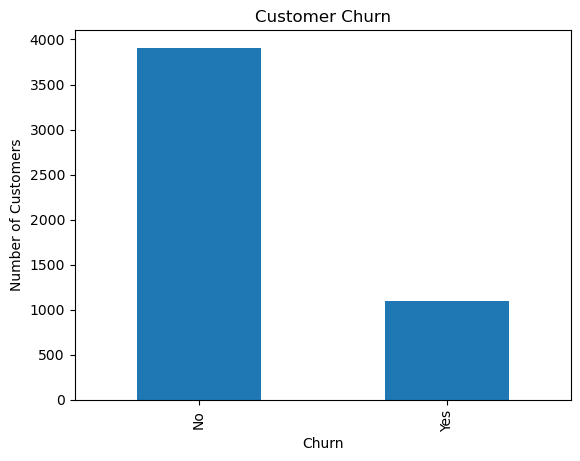

In [30]:
df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [31]:
contract_churn = pd.crosstab(
    df['Contract_Type'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn)

Churn                 No        Yes
Contract_Type                      
Monthly        75.571688  24.428312
Quarterly      79.545455  20.454545
Yearly         83.900929  16.099071


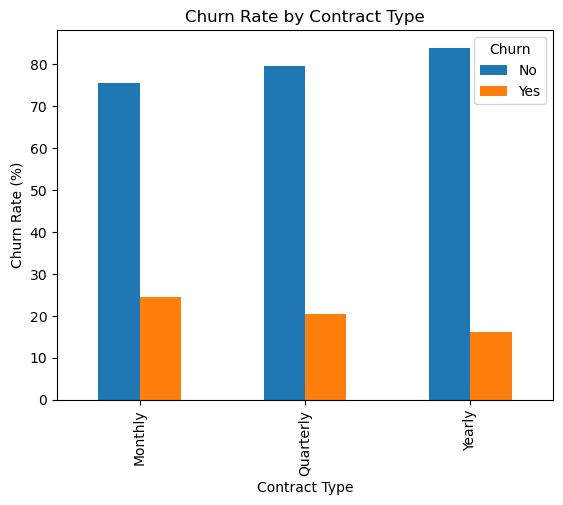

In [34]:
contract_churn.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

In [35]:
df['Tenure_Group'] = pd.cut(
    df['Tenure_Months'],
    bins=[0, 12, 24, 36, 48, 60],
    labels=['0-12', '13-24', '25-36', '37-48', '49-60']
)

In [36]:
tenure_churn = (
    df.groupby('Tenure_Group', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(tenure_churn)

Tenure_Group
0-12     31.486146
13-24    24.348341
25-36    16.897747
37-48    12.931034
49-60     8.510638
Name: Churn, dtype: float64


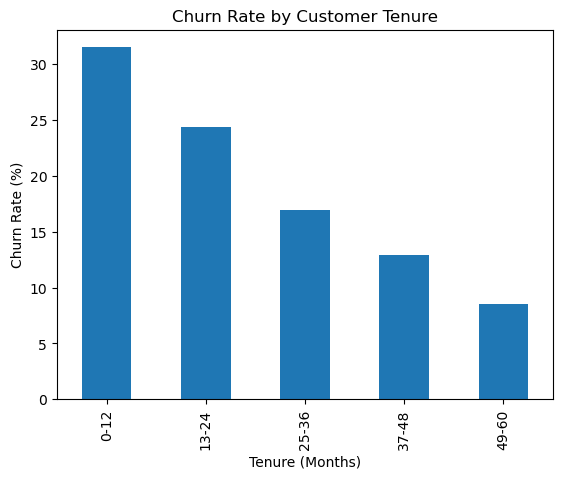

In [37]:
tenure_churn.plot(kind='bar')

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.show()

In [38]:
city_churn = (
    df.groupby('City')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(city_churn)

City
Chennai      24.898785
Hyderabad    23.383085
Bengaluru    22.747748
Kolkata      21.606648
Delhi        21.478873
Pune         20.974576
Mumbai       20.907618
Jaipur       20.058997
Ahmedabad    19.948187
Kochi        18.750000
Name: Churn, dtype: float64


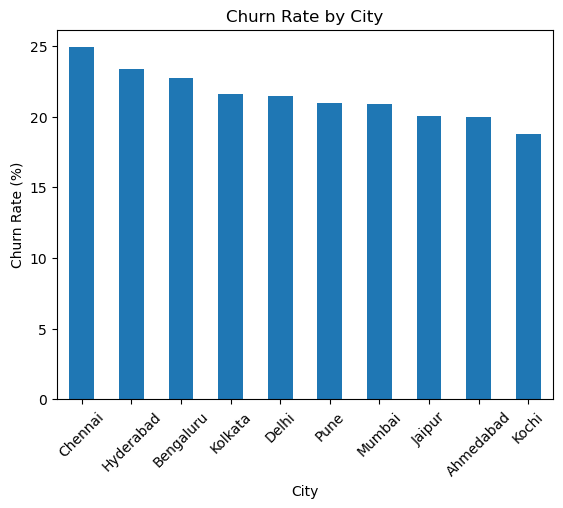

In [39]:
city_churn.plot(kind='bar')

plt.title('Churn Rate by City')
plt.xlabel('City')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [40]:
df['Charge_Group'] = pd.qcut(
    df['Monthly_Charges'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

In [41]:
charge_churn = (
    df.groupby('Charge_Group', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(charge_churn)

Charge_Group
Low            17.360000
Medium-Low     20.615385
Medium-High    22.333333
High           26.960000
Name: Churn, dtype: float64


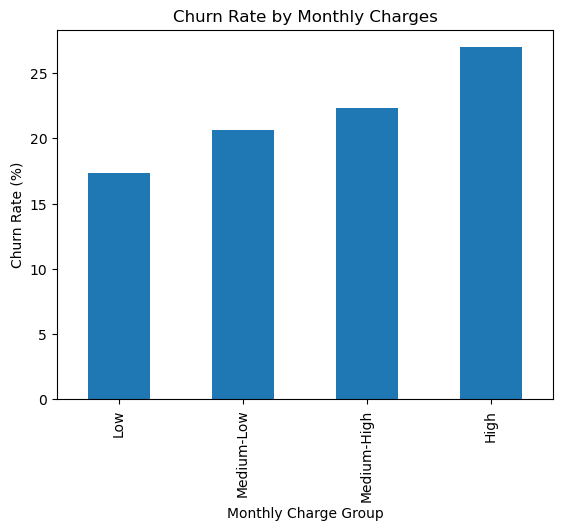

In [42]:
charge_churn.plot(kind='bar')
plt.title('Churn Rate by Monthly Charges')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate (%)')
plt.show()

In [43]:
support_churn = (
    df.groupby('Support_Calls')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(support_churn)

Support_Calls
0.0      12.500000
1.0      15.697674
2.0      19.711538
3.0      24.417314
4.0      33.965844
5.0      37.295082
6.0      41.666667
7.0      57.692308
8.0      66.666667
9.0     100.000000
10.0    100.000000
Name: Churn, dtype: float64


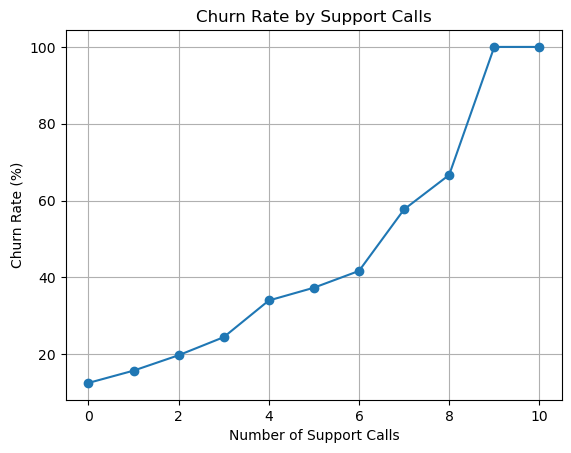

In [44]:
support_churn.plot(kind='line', marker='o')

plt.title('Churn Rate by Support Calls')
plt.xlabel('Number of Support Calls')
plt.ylabel('Churn Rate (%)')
plt.grid()
plt.show()

In [45]:
payment_churn = (
    df.groupby('Payment_Method')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print(payment_churn)

Payment_Method
Cash             26.095618
Credit Card      23.765996
UPI              20.961538
Bank Transfer    20.554985
Debit Card       19.747417
Name: Churn, dtype: float64


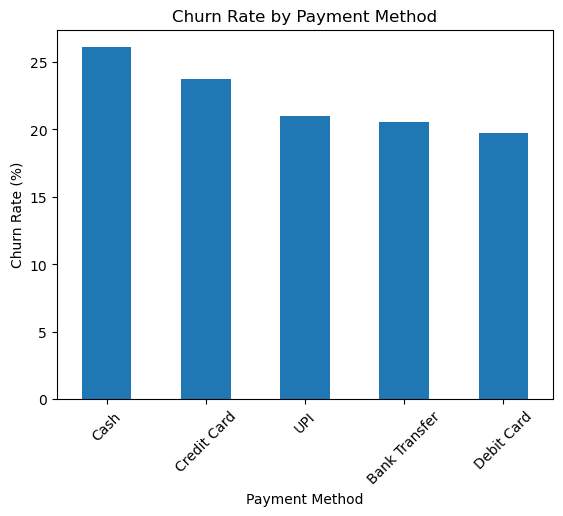

In [46]:
payment_churn.plot(kind='bar')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [47]:
satisfaction_churn = (
    df.groupby('Satisfaction_Score')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(satisfaction_churn)

Satisfaction_Score
1.0       0.000000
2.0     100.000000
3.0      73.333333
4.0      50.236967
5.0      32.653061
6.0      24.213287
7.0      18.899676
8.0      13.326653
9.0      12.285714
10.0      9.638554
Name: Churn, dtype: float64


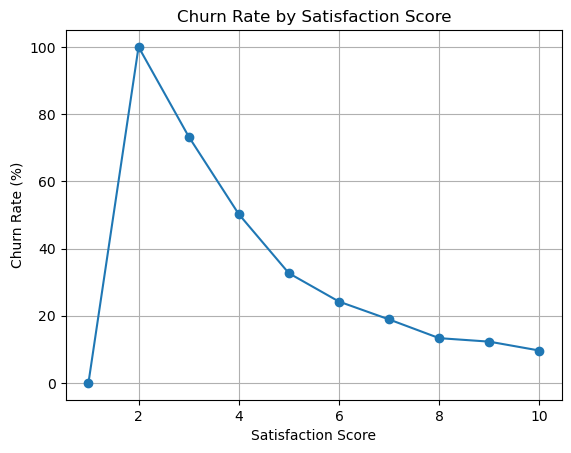

In [48]:
satisfaction_churn.plot(kind='line', marker='o')

plt.title('Churn Rate by Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Churn Rate (%)')
plt.grid()
plt.show()

In [49]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

In [51]:
age_churn = (
    df.groupby('Age_Group', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(age_churn)

Age_Group
18-25    22.788204
26-35    23.672566
36-45    21.100917
46-55    21.685509
56-65    21.139102
66+      19.668737
Name: Churn, dtype: float64


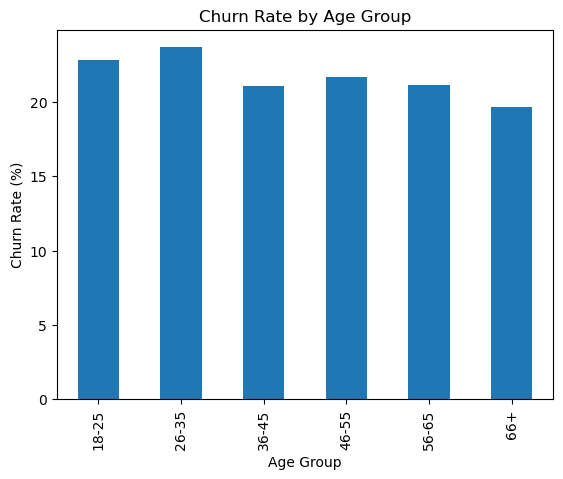

In [52]:
age_churn.plot(kind='bar')

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.show()

In [53]:
revenue_by_plan = (
    df.groupby('Plan_Type')['Total_Charges']
    .sum()
    .sort_values(ascending=False)
)

print(revenue_by_plan)


Plan_Type
Standard    55809631.07
Basic       32870040.36
Premium     32485005.22
Name: Total_Charges, dtype: float64


In [54]:
churn_by_plan = (
    df.groupby('Plan_Type')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print(churn_by_plan)

Plan_Type
Basic       18.812990
Premium     27.650728
Standard    21.669627
Name: Churn, dtype: float64


In [55]:
plan_analysis = pd.DataFrame({
    'Revenue': revenue_by_plan,
    'Churn_Rate': churn_by_plan
})

print(plan_analysis)

               Revenue  Churn_Rate
Plan_Type                         
Basic      32870040.36   18.812990
Premium    32485005.22   27.650728
Standard   55809631.07   21.669627
